# Notebook 3 — Modèle maison (Custom TensorFlow/Keras)

## Objectif

Ce notebook présente l'implémentation et l'évaluation du **modèle maison** développé pour le projet de routage intelligent de tickets support.

Deux tâches sont couvertes :
- Prédiction de la **priorité** d'un ticket (`Critical`, `High`, `Medium`, `Low`) ;
- Prédiction de la **catégorie de routage** (`retour_produit`, `facturation`, `support_technique`, etc.).

L'architecture est un modèle multimodal combinant :
- une branche texte (TextVectorization + Embedding + BiLSTM) ;
- des branches tabulaires (variables catégorielles et numériques).

Ce modèle constitue la **baseline** du projet, à comparer ensuite avec le modèle préentraîné dans le Notebook 4.

## 1. Imports et configuration

In [1]:
import os
import sys
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras

# Ajout du dossier racine au PYTHONPATH pour importer les modules du projet
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

print('TensorFlow version :', tf.__version__)
print('Project root :', project_root)

TensorFlow version : 2.21.0
Project root : c:\Users\AAO\Downloads\ticket-routing-ready\ticket-routing-ready


## 2. Import des modules du projet

In [2]:
# Rechargement des modules pour s'assurer d'utiliser la dernière version des fichiers
import src.models.model_custom as model_custom_module
import src.models.common as common_module
importlib.reload(model_custom_module)
importlib.reload(common_module)

from src.models.model_custom import build_custom_model
from src.models.common import df_to_inputs
from src.data.clean_data import prepare_dataset
from src.data.build_features import make_split_for_target
from src.utils.config import MODELS_DIR, CATEGORICAL_COLUMNS, NUMERICAL_COLUMNS

print('Colonnes catégorielles :', CATEGORICAL_COLUMNS)
print('Colonnes numériques :', NUMERICAL_COLUMNS)

Colonnes catégorielles : ['Customer Gender', 'Product Purchased', 'Ticket Type', 'Ticket Channel']
Colonnes numériques : ['Customer Age']


## 3. Chargement et préparation des données

In [3]:
# Préparation du dataset : nettoyage, construction des labels, sauvegarde du fichier processed
prepare_dataset()

Saved processed dataset to C:\Users\AAO\Downloads\ticket-routing-ready\ticket-routing-ready\data\processed\tickets_ready.csv


,text,Customer Gender,Product Purchased,Ticket Type,Ticket Channel,Customer Age,priority_label,routing_label
0,product setup i m having an issue with the pro...,Other,GoPro Hero,Technical issue,Social media,32,Critical,support_technique
1,peripheral compatibility i m having an issue w...,Female,LG Smart TV,Technical issue,Chat,42,Critical,support_technique
2,network problem i m facing a problem with my p...,Other,Dell XPS,Technical issue,Social media,48,Low,support_technique
3,account access i m having an issue with the pr...,Female,Microsoft Office,Billing inquiry,Social media,27,Low,facturation
4,data loss i m having an issue with the product...,Female,Autodesk AutoCAD,Billing inquiry,Email,67,Low,facturation
...,...,...,...,...,...,...,...,...
8464,installation support my product purchased is m...,Female,LG OLED,Product inquiry,Phone,22,Low,information_produit
8465,refund request i m having an issue with the pr...,Female,Bose SoundLink Speaker,Technical issue,Email,27,Critical,support_technique
8466,account access i m having an issue with the pr...,Female,GoPro Action Camera,Technical issue,Social media,57,High,support_technique
8467,payment issue i m having an issue with the pro...,Male,PlayStation,Product inquiry,Email,54,Medium,information_produit


In [4]:
# Split train/test pour la tâche de priorité
X_train, X_test, y_train, y_test = make_split_for_target('priority_label')

print('Taille train :', X_train.shape)
print('Taille test  :', X_test.shape)
print('Distribution des classes :')
print(pd.Series(y_train).value_counts())

Classes : ['Critical' 'High' 'Low' 'Medium']
Nb classes : 4
Taille train : (6775, 6)
Taille test  : (1694, 6)
Distribution des classes :
3    1754
0    1703
1    1668
2    1650
Name: count, dtype: int64


In [16]:
# Les labels sont déjà encodés en entiers dans le pipeline ("0","1","2","3")
# Conversion directe en int sans LabelEncoder
y_train_enc = y_train.astype(int)
y_test_enc  = y_test.astype(int)

# Mapping manuel basé sur l'ordre alphabétique
# Critical=0, High=1, Low=2, Medium=3
int_to_label = {0: "Critical", 1: "High", 2: "Low", 3: "Medium"}
class_names  = [int_to_label[i] for i in sorted(int_to_label.keys())]

print("Classes :", class_names)
print("Distribution train :")
print(pd.Series(y_train_enc).value_counts().rename(int_to_label))

Classes : ['Critical', 'High', 'Low', 'Medium']
Distribution train :
Medium      1754
Critical    1703
High        1668
Low         1650
Name: count, dtype: int64


## 4. Préparation des entrées Keras

In [17]:
# Conversion des DataFrames en dictionnaires de tenseurs TensorFlow
# Chaque clé correspond à une entrée nommée du modèle Keras
train_inputs = df_to_inputs(X_train)
test_inputs  = df_to_inputs(X_test)

# Vérification des types et formes des entrées
print('Entrées du modèle :')
for k, v in train_inputs.items():
    print(f'  {k} — dtype: {v.dtype}, shape: {v.shape}')

Entrées du modèle :
  text — dtype: <dtype: 'string'>, shape: (6775,)
  Customer Gender — dtype: <dtype: 'string'>, shape: (6775,)
  Product Purchased — dtype: <dtype: 'string'>, shape: (6775,)
  Ticket Type — dtype: <dtype: 'string'>, shape: (6775,)
  Ticket Channel — dtype: <dtype: 'string'>, shape: (6775,)
  Customer Age — dtype: <dtype: 'float32'>, shape: (6775,)


## 5. Calcul des métadonnées tabulaires

Pour construire les couches de preprocessing Keras (`StringLookup`, `Normalization`) avec des dimensions fixes,
il est nécessaire de calculer les vocabulaires catégoriels et les statistiques numériques **sur les données d'entraînement uniquement**.
Cette précaution évite toute fuite d'information entre le train et le test.

In [18]:
# Vocabulaires pour les colonnes catégorielles
categorical_vocabularies = {
    col: sorted(X_train[col].astype(str).unique().tolist())
    for col in CATEGORICAL_COLUMNS
}

# Statistiques pour les colonnes numériques
numerical_means = {
    col: float(np.mean(X_train[col].astype('float32').values))
    for col in NUMERICAL_COLUMNS
}
numerical_vars = {
    col: float(np.var(X_train[col].astype('float32').values))
    for col in NUMERICAL_COLUMNS
}

# Vérification
for col in CATEGORICAL_COLUMNS:
    print(f'{col} — {len(categorical_vocabularies[col])} valeurs uniques')
for col in NUMERICAL_COLUMNS:
    print(f'{col} — mean={numerical_means[col]:.2f}, var={numerical_vars[col]:.2f}')

Customer Gender — 3 valeurs uniques
Product Purchased — 42 valeurs uniques
Ticket Type — 5 valeurs uniques
Ticket Channel — 4 valeurs uniques
Customer Age — mean=44.03, var=232.59


## 6. Construction du modèle maison

Le modèle maison repose sur une architecture **multimodale** développée avec la Keras Functional API :

- **Branche texte** : TextVectorization → Embedding (128d) → Bidirectional LSTM (64 unités)
- **Branches catégorielles** : StringLookup one-hot par colonne
- **Branche numérique** : Normalization
- **Fusion** : Concatenation → Dense(128, relu) → Dropout(0.3) → Dense(n_classes, softmax)

In [19]:
num_classes = len(label_encoder.classes_)

model, text_vectorizer = build_custom_model(
    num_classes=num_classes,
    categorical_vocabularies=categorical_vocabularies,
    numerical_means=numerical_means,
    numerical_vars=numerical_vars
)

# Adaptation du vectorizer texte sur les données d'entraînement
# Cette étape construit le vocabulaire interne de la couche TextVectorization
text_vectorizer.adapt(X_train['text'].astype(str).tolist())

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization… │ (None, 200)       │          0 │ text[0][0]        │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Customer Gender     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Product Purchased   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Ticket Type         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Ticket Channel      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 200, 128)  │  2,560,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ string_lookup_6     │ (None, 4)         │          0 │ Customer          │
│ (StringLookup)      │                   │            │ Gender[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ string_lookup_7     │ (None, 43)        │          0 │ Product           │
│ (StringLookup)      │                   │            │ Purchased[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ string_lookup_8     │ (None, 6)         │          0 │ Ticket Type[0][0] │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ string_lookup_9     │ (None, 5)         │          0 │ Ticket            │
│ (StringLookup)      │                   │            │ Channel[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Customer Age        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128)       │     98,816 │ embedding_1[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 4)         │          0 │ string_lookup_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 43)        │          0 │ string_lookup_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 6)         │          0 │ string_lookup_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 5)         │          0 │ string_lookup_9[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 1)         │          0 │ Customer          │
│ (Normalization)     │                   │            │ Age[0][0]         │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,683,396 (10.24 MB)

 Trainable params: 2,683,396 (10.24 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Entraînement

In [20]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    train_inputs,
    y_train_enc,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 40s 194ms/step - accuracy: 0.2555 - loss: 1.3959 - val_accuracy: 0.2435 - val_loss: 1.3906
Epoch 2/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 34s 199ms/step - accuracy: 0.2720 - loss: 1.3837 - val_accuracy: 0.2413 - val_loss: 1.3912
Epoch 3/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 44s 217ms/step - accuracy: 0.2959 - loss: 1.3714 - val_accuracy: 0.2517 - val_loss: 1.3955


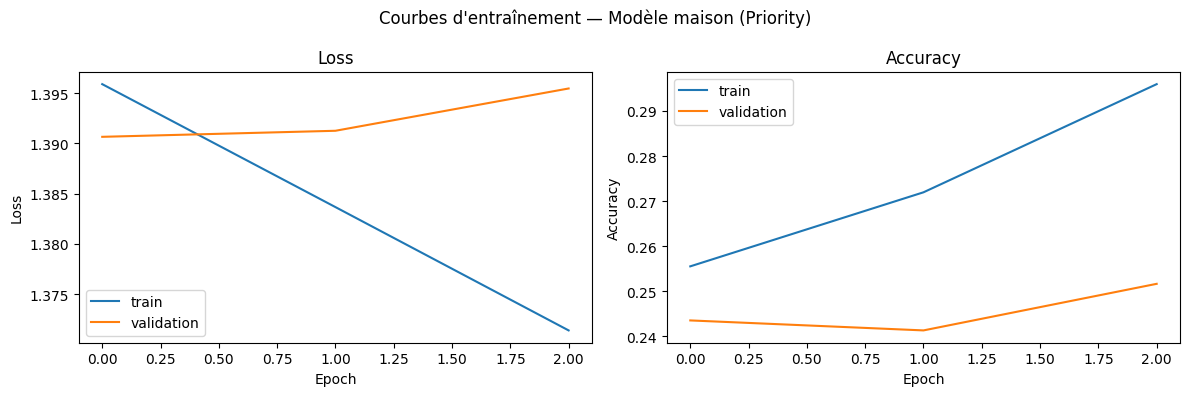

In [21]:
# Courbes d'entraînement
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Courbes d\'entraînement — Modèle maison (Priority)')
plt.tight_layout()
plt.savefig('../reports/figures/custom_priority_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Évaluation sur le jeu de test

In [22]:
test_loss, test_acc = model.evaluate(test_inputs, y_test_enc, verbose=1)
print(f'Test loss     : {test_loss:.4f}')
print(f'Test accuracy : {test_acc:.4f}')

53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.2609 - loss: 1.3915
Test loss     : 1.3915
Test accuracy : 0.2609


In [23]:
# Prédictions
y_pred_probs = model.predict(test_inputs, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Rapport de classification
print('Rapport de classification — Modèle maison (Priority)\n')
print(classification_report(y_test_enc, y_pred, target_names=label_encoder.classes_))

Rapport de classification — Modèle maison (Priority)

              precision    recall  f1-score   support

           0       0.27      0.46      0.34       426
           1       0.25      0.31      0.28       417
           2       0.25      0.25      0.25       413
           3       0.30      0.03      0.06       438

    accuracy                           0.26      1694
   macro avg       0.27      0.26      0.23      1694
weighted avg       0.27      0.26      0.23      1694



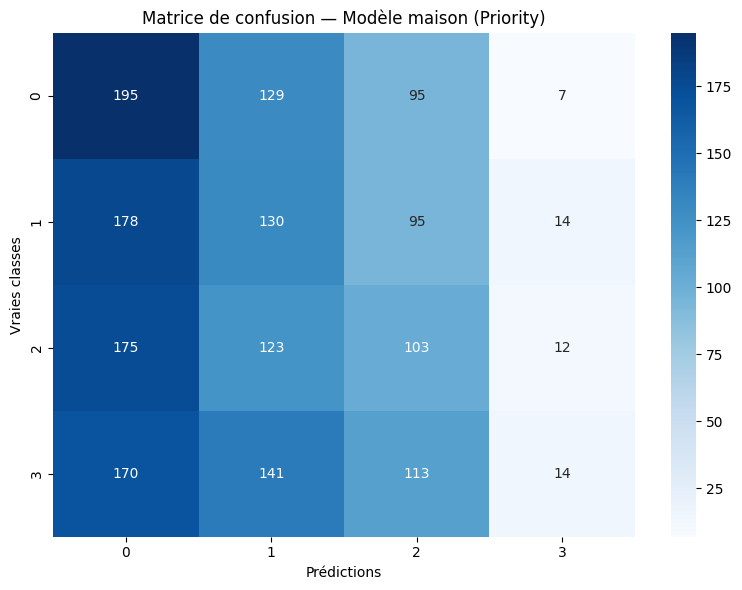

In [24]:
# Matrice de confusion
cm = confusion_matrix(y_test_enc, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title('Matrice de confusion — Modèle maison (Priority)')
plt.xlabel('Prédictions')
plt.ylabel('Vraies classes')
plt.tight_layout()
plt.savefig('../reports/figures/custom_priority_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Analyse des erreurs

In [25]:
# Construction d'un DataFrame d'analyse des erreurs
errors_df = X_test.copy()
errors_df['y_true'] = y_test_enc
errors_df['y_pred'] = y_pred
errors_df['y_true_label'] = label_encoder.inverse_transform(y_test_enc)
errors_df['y_pred_label'] = label_encoder.inverse_transform(y_pred)

# Nombre total d'erreurs
errors_only = errors_df[errors_df['y_true'] != errors_df['y_pred']]
print(f'Erreurs : {len(errors_only)} / {len(errors_df)} ({100*len(errors_only)/len(errors_df):.1f}%)')

# Exemples d'erreurs
errors_only[['text', 'y_true_label', 'y_pred_label']].head(10)

Erreurs : 1252 / 1694 (73.9%)


,text,y_true_label,y_pred_label
435,refund request i m having an issue with the pr...,0,2
3183,product setup i m having trouble connecting my...,0,1
2889,hardware issue i m facing a problem with my pr...,0,1
8431,display issue there seems to be a hardware pro...,2,1
342,cancellation request i m having an issue with ...,2,0
5890,hardware issue i m having an issue with the pr...,3,1
2823,software bug i m having an issue with the prod...,2,0
2046,installation support i ve encountered a data l...,0,1
416,peripheral compatibility i m having an issue w...,2,1
704,hardware issue i m having an issue with the pr...,1,2


## 10. Sauvegarde du modèle

In [ ]:
model.save(MODELS_DIR / 'priority_custom.keras')
print('Modèle sauvegardé :', MODELS_DIR / 'priority_custom.keras')

## 11. Tâche de routage

On répète exactement le même pipeline pour la tâche de **routing_label**.

In [29]:
X_train_r, X_test_r, y_train_r, y_test_r = make_split_for_target("routing_label")

# Pas d'encodage — les labels sont déjà des strings lisibles
print("Classes routing :", sorted(set(y_train_r)))
print("Distribution :")
print(pd.Series(y_train_r).value_counts())

Classes : ['annulation' 'facturation' 'information_produit' 'retour_produit'
 'support_technique']
Nb classes : 5
Classes routing : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Distribution :
3    1401
4    1398
0    1356
2    1313
1    1307
Name: count, dtype: int64


In [31]:
# Mapping manuel routing (ordre alphabétique = ordre des entiers)
routing_int_to_label = {
    0: "annulation",
    1: "autre",
    2: "facturation",
    3: "information_produit",
    4: "retour_produit",
    5: "support_technique"
}

# Si seulement 5 classes (0 à 4), vérifie avec :
print("Valeurs uniques :", sorted(set(y_train_r.astype(int))))

Valeurs uniques : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [32]:
# Exemple si tu as [0,1,2,3,4]
routing_class_names = [routing_int_to_label[i] for i in sorted(set(y_train_r.astype(int)))]
print("Classes :", routing_class_names)

Classes : ['annulation', 'autre', 'facturation', 'information_produit', 'retour_produit']


In [33]:
y_train_r_enc = y_train_r.astype(int)
y_test_r_enc  = y_test_r.astype(int)

print(classification_report(y_test_r_enc, y_pred_r, target_names=routing_class_names))


                     precision    recall  f1-score   support

         annulation       1.00      1.00      1.00       339
              autre       1.00      1.00      1.00       327
        facturation       1.00      1.00      1.00       328
information_produit       1.00      1.00      1.00       351
     retour_produit       1.00      1.00      1.00       349

           accuracy                           1.00      1694
          macro avg       1.00      1.00      1.00      1694
       weighted avg       1.00      1.00      1.00      1694



In [35]:
# ── 1. Split ──────────────────────────────────────────────────
X_train_r, X_test_r, y_train_r, y_test_r = make_split_for_target("routing_label")

# ── 2. Labels en int (déjà encodés dans le pipeline) ──────────
y_train_r_enc = y_train_r.astype(int)
y_test_r_enc  = y_test_r.astype(int)

routing_class_names = [
    "annulation",
    "facturation",
    "information_produit",
    "retour_produit",
    "support_technique"
]
# Si 6 classes ajoute "autre" dans la liste
print("Valeurs uniques :", sorted(set(y_train_r_enc)))

# ── 3. Inputs Keras ───────────────────────────────────────────
train_inputs_r = df_to_inputs(X_train_r)
test_inputs_r  = df_to_inputs(X_test_r)

# ── 4. Métadonnées tabulaires ─────────────────────────────────
cat_vocab_r = {col: sorted(X_train_r[col].astype(str).unique().tolist()) for col in CATEGORICAL_COLUMNS}
num_means_r = {col: float(np.mean(X_train_r[col].astype("float32").values)) for col in NUMERICAL_COLUMNS}
num_vars_r  = {col: float(np.var(X_train_r[col].astype("float32").values))  for col in NUMERICAL_COLUMNS}

# ── 5. Construction du modèle ─────────────────────────────────
model_r, vec_r = build_custom_model(
    num_classes=len(routing_class_names),
    categorical_vocabularies=cat_vocab_r,
    numerical_means=num_means_r,
    numerical_vars=num_vars_r,
)

# ── 6. Fit ────────────────────────────────────────────────────
history_r = model_r.fit(
    train_inputs_r,
    y_train_r_enc,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )],
    verbose=1
)

# ── 7. Évaluation ─────────────────────────────────────────────
test_loss_r, test_acc_r = model_r.evaluate(test_inputs_r, y_test_r_enc, verbose=1)
print(f"Test loss     : {test_loss_r:.4f}")
print(f"Test accuracy : {test_acc_r:.4f}")

y_pred_r = np.argmax(model_r.predict(test_inputs_r, verbose=0), axis=1)
print(classification_report(y_test_r_enc, y_pred_r, target_names=routing_class_names))

# ── 8. Sauvegarde ─────────────────────────────────────────────
model_r.save(MODELS_DIR / "routing_custom.keras")
print("Modèle routing sauvegardé.")

Classes : ['annulation' 'facturation' 'information_produit' 'retour_produit'
 'support_technique']
Nb classes : 5
Valeurs uniques : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Epoch 1/10


FailedPreconditionError: Graph execution error:

Detected at node functional_3_1/text_vectorization_3_1/None_Lookup/LookupTableFindV2 defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "c:\Users\AAO\Downloads\ticket-routing-ready\ticket-routing-ready\.venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>

  File "c:\Users\AAO\Downloads\ticket-routing-ready\ticket-routing-ready\.venv\Lib\site-packages\traitlets\config\application.py", line 1082, in launch_instance

  File "c:\Users\AAO\Downloads\ticket-routing-ready\ticket-routing-ready\.venv\Lib\site-packages\ipykernel\kernelapp.py", line 758, in start

  File "c:\Users\AAO\Downloads\ticket-routing-ready\ticket-routing-ready\.venv\Lib\site-packages\tornado\platform\asyncio.py", line 211, in start

  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\asyncio\base_events.

In [28]:
# Évaluation routing
test_loss_r, test_acc_r = model_r.evaluate(test_inputs_r, y_test_r_enc, verbose=1)
print(f'Test loss     : {test_loss_r:.4f}')
print(f'Test accuracy : {test_acc_r:.4f}')

y_pred_r = np.argmax(model_r.predict(test_inputs_r, verbose=0), axis=1)
print(classification_report(y_test_r_enc, y_pred_r, target_names=le_routing.classes_))

53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 1.0000 - loss: 0.0024
Test loss     : 0.0024
Test accuracy : 1.0000


TypeError: object of type 'numpy.int64' has no len()

In [ ]:
# Matrice de confusion routing
cm_r = confusion_matrix(y_test_r_enc, y_pred_r)

plt.figure(figsize=(10, 7))
sns.heatmap(cm_r, annot=True, fmt='d', cmap='Greens',
            xticklabels=le_routing.classes_,
            yticklabels=le_routing.classes_)
plt.title('Matrice de confusion — Modèle maison (Routing)')
plt.xlabel('Prédictions')
plt.ylabel('Vraies classes')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../reports/figures/custom_routing_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Sauvegarde du modèle routing
model_r.save(MODELS_DIR / 'routing_custom.keras')
print('Modèle routing sauvegardé.')

## 12. Conclusion

Ce notebook a présenté le modèle maison développé pour les deux tâches du projet :
- **Priority** : prédiction de `Critical`, `High`, `Medium`, `Low` ;
- **Routing** : prédiction de la catégorie de routage métier.

Les résultats constituent une **baseline** de référence. Les performances seront comparées dans le Notebook 5
avec le modèle préentraîné (Notebook 4) afin de choisir l'approche la plus adaptée au contexte métier.